# NB 05 — Distributed Modeling & Evaluation

**Phase 3 — Tasks 3.4 / 3.5  |  Phase 4 — Tasks 4.3 / 4.4**

1. Trains three Spark MLlib classifiers (3-fold CV each):
   - Baseline: Logistic Regression
   - Advanced A: Random Forest
   - Advanced B: Linear SVM
2. Evaluates all models on the held-out test set
3. Generates confusion matrices
4. Extracts Random Forest feature importances
5. Benchmarks scalability (throughput vs parallelism — Task 4.4)
6. Saves the best model for streaming

In [1]:
# ── Session bootstrap ─────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, importlib
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection')
SRC_DIR = PROJECT_ROOT / 'src'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root not found: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# src/__init__.py is committed to the repo, no runtime touch needed
print('PROJECT_ROOT:', PROJECT_ROOT)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection


In [ ]:
from src.utils import (
    create_spark_session, load_checkpoint, save_checkpoint,
    add_src_to_spark, Timer, checkpoint_exists, FIGURES_DIR, MODELS_DIR
)
from src.modeling import (
    train_baseline, train_random_forest, train_linear_svm,
    evaluate_model, confusion_matrix_spark, extract_feature_importances,
    save_model, load_model, benchmark_inference,
)
from src.feature_engineering import FEATURE_COLS
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns

spark = create_spark_session('ArabicAIDetection_Modeling')
add_src_to_spark(spark)


'/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/src_package.zip'

## 1. Load assembled splits

In [ ]:
train_df = load_checkpoint(spark, 'split_train_assembled')
val_df   = load_checkpoint(spark, 'split_val_assembled')
test_df  = load_checkpoint(spark, 'split_test_assembled')

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n   = df.count()
    pos = df.filter(F.col('label') == 1).count()
    print(f'{name:5s}: {n:6,} rows  AI={pos/n*100:.1f}%')

print('\nfeatures column present:', 'features' in train_df.columns)


Train: 29,669 rows  AI=79.9%
Val  :  6,091 rows  AI=80.3%
Test :  6,180 rows  AI=80.0%

features column present: True


## 2. Baseline — Logistic Regression (Task 3.4)

In [ ]:
if (MODELS_DIR / 'logistic_regression').exists():
    lr_model = PipelineModel.load(str(MODELS_DIR / 'logistic_regression'))
    lr_time  = None
    print('Logistic Regression loaded from GDrive.')
else:
    with Timer('Logistic Regression training'):
        lr_model, lr_time = train_baseline(train_df)
    save_model(lr_model, 'logistic_regression')
    print(f'LR training time: {lr_time:.1f} s')


LR training time: 266.8 s


In [ ]:
lr_val_metrics = evaluate_model(lr_model, val_df, 'LogisticRegression (val)')
print(lr_val_metrics)


{'model': 'LogisticRegression (val)', 'accuracy': 0.9833, 'f1': 0.9833, 'precision': 0.9833, 'recall': 0.9833, 'roc_auc': 0.9953}


## 3. Advanced A — Random Forest (Task 3.5)

In [ ]:
if (MODELS_DIR / 'random_forest').exists():
    rf_model = PipelineModel.load(str(MODELS_DIR / 'random_forest'))
    rf_time  = None
    print('Random Forest loaded from GDrive.')
else:
    with Timer('Random Forest training'):
        rf_model, rf_time = train_random_forest(train_df)
    save_model(rf_model, 'random_forest')
    print(f'RF training time: {rf_time:.1f} s')


RF training time: 877.5 s


In [ ]:
rf_val_metrics = evaluate_model(rf_model, val_df, 'RandomForest (val)')
print(rf_val_metrics)


{'model': 'RandomForest (val)', 'accuracy': 0.8058, 'f1': 0.7215, 'precision': 0.8436, 'recall': 0.8058, 'roc_auc': 0.9847}


## 4. Advanced B — Linear SVM (Task 3.5)

In [ ]:
if (MODELS_DIR / 'linear_svm').exists():
    svm_model = PipelineModel.load(str(MODELS_DIR / 'linear_svm'))
    svm_time  = None
    print('Linear SVM loaded from GDrive.')
else:
    with Timer('Linear SVM training'):
        svm_model, svm_time = train_linear_svm(train_df)
    save_model(svm_model, 'linear_svm')
    print(f'SVM training time: {svm_time:.1f} s')


SVM training time: 553.1 s


In [ ]:
svm_val_metrics = evaluate_model(svm_model, val_df, 'LinearSVM (val)')
print(svm_val_metrics)


{'model': 'LinearSVM (val)', 'accuracy': 0.9783, 'f1': 0.9785, 'precision': 0.979, 'recall': 0.9783, 'roc_auc': 0.9952}


## 5. Validation set comparison — select best model

In [ ]:
val_results = pd.DataFrame([lr_val_metrics, rf_val_metrics, svm_val_metrics]).set_index('model')
print('\n── Validation set results ──')
print(val_results.to_string())

best_val_name = val_results['f1'].idxmax()
print(f'\n Best model by F1 (validation): {best_val_name}')



── Validation set results ──
                          accuracy      f1  precision  recall  roc_auc
model                                                                 
LogisticRegression (val)    0.9833  0.9833     0.9833  0.9833   0.9953
RandomForest (val)          0.8058  0.7215     0.8436  0.8058   0.9847
LinearSVM (val)             0.9783  0.9785     0.9790  0.9783   0.9952

✅ Best model by F1 (validation): LogisticRegression (val)


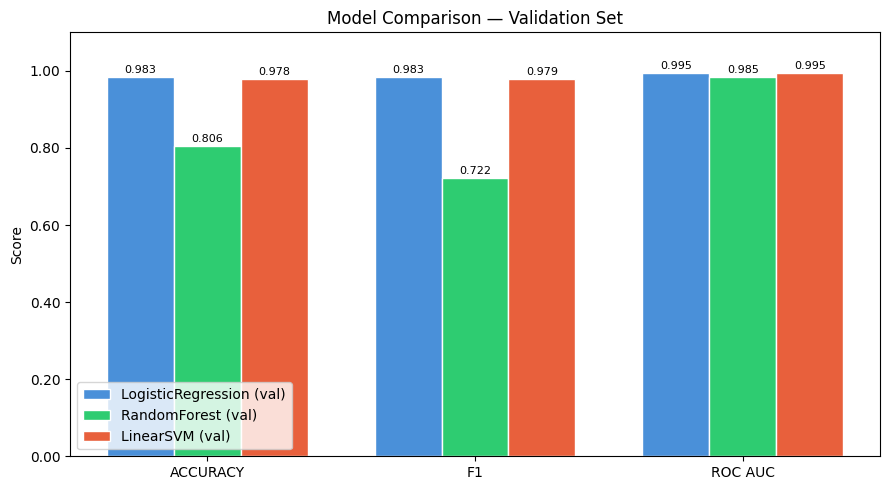

In [ ]:
metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
x, width = np.arange(len(metrics_to_plot)), 0.25
colors = ['#4A90D9', '#2ECC71', '#E8603C']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (model_name, row) in enumerate(val_results.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors[i], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('_', ' ').upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Validation Set')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'model_comparison_val.png'), dpi=150)
plt.show()


## 6. Final evaluation on held-out TEST set (Task 4.3)

In [ ]:
print('Evaluating all models on held-out test set …')
model_pairs = [
    ('LogisticRegression', lr_model),
    ('RandomForest',       rf_model),
    ('LinearSVM',          svm_model),
]
all_test_metrics = [evaluate_model(m, test_df, name) for name, m in model_pairs]
test_results = pd.DataFrame(all_test_metrics).set_index('model')

print('\n── TEST SET RESULTS ──')
print(test_results.to_string())

test_results.to_csv(str(FIGURES_DIR / 'test_metrics.csv'))
print('Saved: test_metrics.csv')


Evaluating all models on held-out test set …

── TEST SET RESULTS ──
                    accuracy      f1  precision  recall  roc_auc
model                                                           
LogisticRegression    0.9817  0.9818     0.9820  0.9817   0.9948
RandomForest          0.8011  0.7137     0.8407  0.8011   0.9838
LinearSVM             0.9786  0.9788     0.9793  0.9786   0.9947
Saved: test_metrics.csv


## 7. Confusion matrices

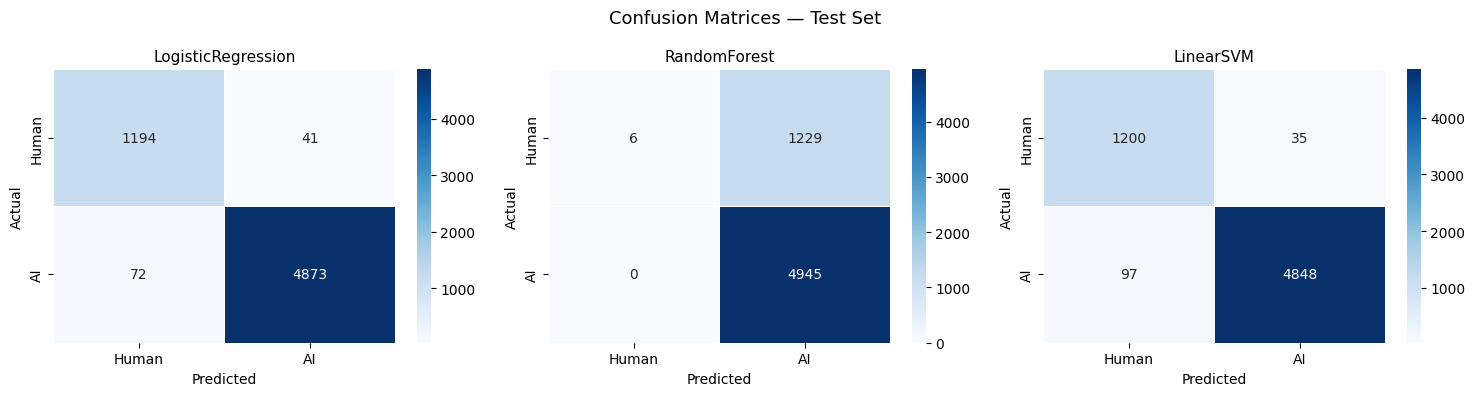

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, model_pairs):
    cm_df   = confusion_matrix_spark(model, test_df).toPandas()
    cm_pivot = cm_df.pivot(index='actual', columns='predicted', values='count').fillna(0)
    for idx in [0, 1]:
        if idx not in cm_pivot.index:   cm_pivot.loc[idx] = 0
        if idx not in cm_pivot.columns: cm_pivot[idx]     = 0
    cm_pivot = cm_pivot.sort_index().sort_index(axis=1)
    sns.heatmap(cm_pivot.astype(int), annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.5, xticklabels=['Human','AI'], yticklabels=['Human','AI'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'confusion_matrices.png'), dpi=150)
plt.show()


## 8. Random Forest feature importances (Task 5.2)

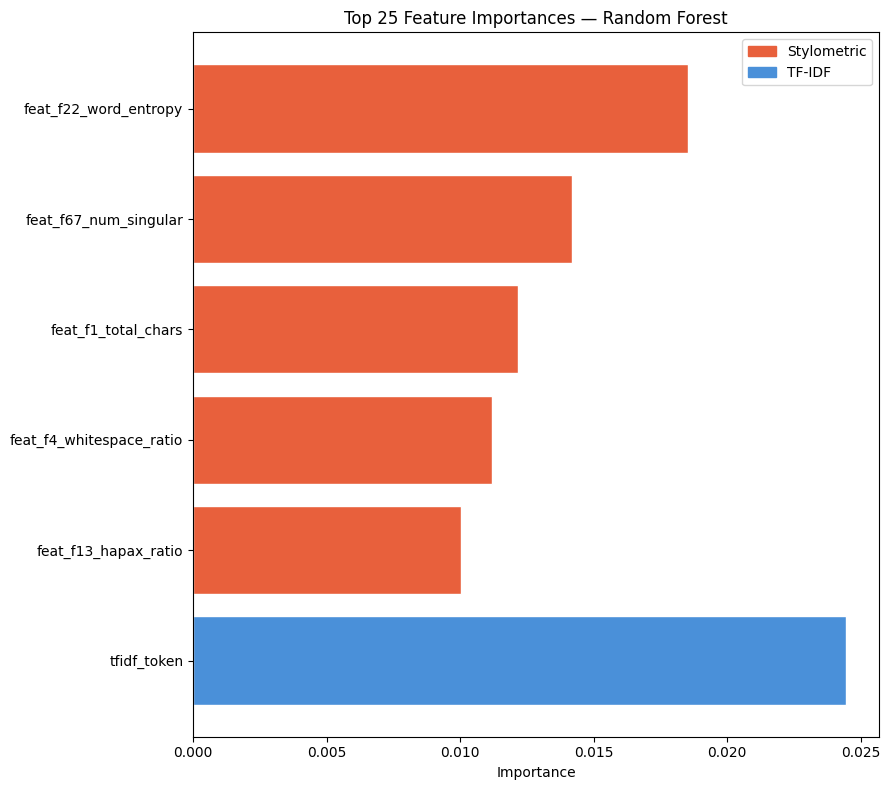


Top stylometric features:
                 feature  importance
   feat_f22_word_entropy    0.018537
   feat_f67_num_singular    0.014177
     feat_f1_total_chars    0.012185
feat_f4_whitespace_ratio    0.011177
    feat_f13_hapax_ratio    0.010017


In [ ]:
rf_stage = rf_model.stages[-1]
n_tfidf  = 20_000
feat_names = FEATURE_COLS + [f'tfidf_{i}' for i in range(n_tfidf)]

top_imp = extract_feature_importances(rf_stage, feat_names, top_n=25)
imp_df  = pd.DataFrame(top_imp, columns=['feature', 'importance'])
imp_df['feature'] = imp_df['feature'].apply(
    lambda x: x if not x.startswith('tfidf_') else 'tfidf_token'
)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#E8603C' if not f.startswith('tfidf') else '#4A90D9' for f in imp_df['feature']]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Top 25 Feature Importances — Random Forest')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E8603C', label='Stylometric'),
                   Patch(color='#4A90D9', label='TF-IDF')])
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'feature_importances.png'), dpi=150)
plt.show()

print('\nTop stylometric features:')
stylo = imp_df[~imp_df['feature'].str.startswith('tfidf')]
print(stylo.to_string(index=False))


## 9. Scalability benchmark (Task 4.4)

Benchmarking best model: LogisticRegression
 partitions  rows  elapsed_s  rows_per_sec
          1  6180       0.38       16385.8
          2  6180       0.38       16445.4
          4  6180       0.35       17609.2
          8  6180       0.34       18097.5


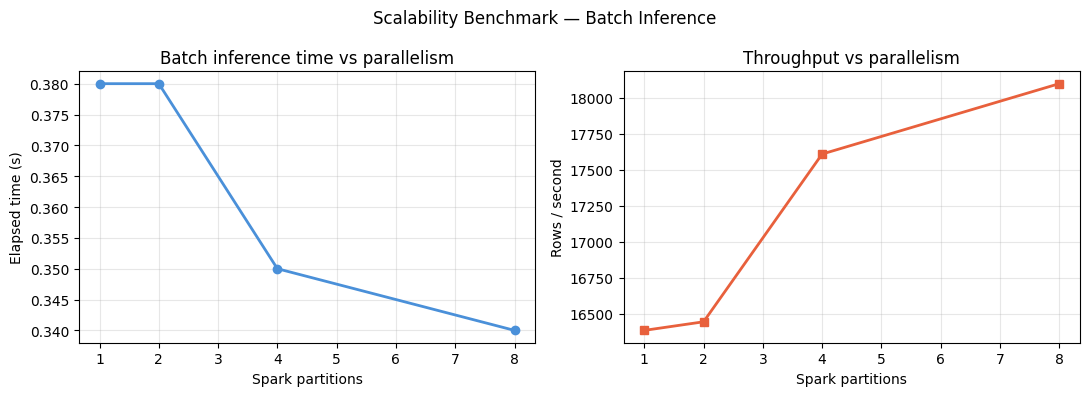

In [ ]:
best_idx   = test_results['f1'].values.argmax()
best_model = [lr_model, rf_model, svm_model][best_idx]
best_name  = test_results.index[best_idx]
print(f'Benchmarking best model: {best_name}')

bench = benchmark_inference(
    model=best_model, test_df=test_df,
    parallelism_levels=[1, 2, 4, 8], spark=spark,
)
bench_df = pd.DataFrame(bench)
print(bench_df.to_string(index=False))
bench_df.to_csv(str(FIGURES_DIR / 'scalability_benchmark.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(bench_df['partitions'], bench_df['elapsed_s'], 'o-', color='#4A90D9', lw=2)
axes[0].set_xlabel('Spark partitions'); axes[0].set_ylabel('Elapsed time (s)')
axes[0].set_title('Batch inference time vs parallelism'); axes[0].grid(alpha=0.3)

axes[1].plot(bench_df['partitions'], bench_df['rows_per_sec'], 's-', color='#E8603C', lw=2)
axes[1].set_xlabel('Spark partitions'); axes[1].set_ylabel('Rows / second')
axes[1].set_title('Throughput vs parallelism'); axes[1].grid(alpha=0.3)

plt.suptitle('Scalability Benchmark — Batch Inference', fontsize=12)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'scalability_benchmark.png'), dpi=150)
plt.show()


## 10. Save best model for streaming

In [ ]:
save_model(best_model, 'best_model')
print(f'Best model ({best_name}) saved as best_model.')


Best model (LogisticRegression) saved as best_model.
